# Notebook Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mlt
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Import des données et vérification du contenu  

In [2]:
#Importer les données 
path=""
health=pd.read_csv(path+"healthcare_synthetic_data.csv", sep=",", header=0)

#On vérifie le contenu
health.head()


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


On regarde le type de chaque variable 

In [3]:
health.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               15000 non-null  object 
 1   Age                      15000 non-null  int64  
 2   Gender                   15000 non-null  int64  
 3   Height_cm                15000 non-null  float64
 4   Weight_kg                15000 non-null  float64
 5   BMI                      15000 non-null  float64
 6   Systolic_BP              15000 non-null  int64  
 7   Diastolic_BP             15000 non-null  int64  
 8   Cholesterol_Total        15000 non-null  int64  
 9   Cholesterol_LDL          15000 non-null  int64  
 10  Cholesterol_HDL          15000 non-null  int64  
 11  Fasting_Blood_Sugar      15000 non-null  int64  
 12  Smoking_Status           15000 non-null  int64  
 13  Alcohol_Consumption      15000 non-null  int64  
 14  Physical_Activity_Leve

On met le bon type pour chaque données (en particulier, on indique les variables qualitatives)

In [4]:
health['Patient_ID'] = pd.Categorical(health['Patient_ID'])
health['Gender'] = pd.Categorical(health['Gender'])
health['Smoking_Status'] = pd.Categorical(health['Smoking_Status'])
health['Alcohol_Consumption'] = pd.Categorical(health['Alcohol_Consumption'])
health['Physical_Activity_Level'] = pd.Categorical(health['Physical_Activity_Level'])
health['Family_History'] = pd.Categorical(health['Family_History'])
health['Stress_Level'] = pd.Categorical(health['Stress_Level'])
health['Sleep_Hours'] = pd.Categorical(health['Sleep_Hours'])
health['Heart_Disease_Risk'] = pd.Categorical(health['Heart_Disease_Risk'])

health.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000


## Modification des données 

### Transformation en Gaussienne 
on définit une fonction pour observer la distribution de nos variables quantitatives 

In [9]:
def plot_quantitative(df):
    # Sélectionner les colonnes numériques du DataFrame
    vars_num = df.select_dtypes(include=['number']).columns
    n_vars = len(vars_num)
    
    if n_vars == 0:
        print("Aucune variable numérique trouvée.")
        return

    # Calculer le nombre de lignes nécessaires pour 3 colonnes dans la grille 
    ncols = 3
    nrows = math.ceil(n_vars / ncols)

    # Créer la figure et les axes
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()  # Aplatir pour itérer facilement

    for i, col in enumerate(vars_num):
        # Création de l'histogramme + densité (kde)
        sns.histplot(df[col], kde=True, stat="density", 
                     color="grey", edgecolor="black",bins=30, 
                     line_kws={"color": "blue"}, ax=axes[i])
        
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Density")
        axes[i].grid(True, alpha=0.3)

    # Supprimer les graphiques vides si n_vars n'est pas un multiple de 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

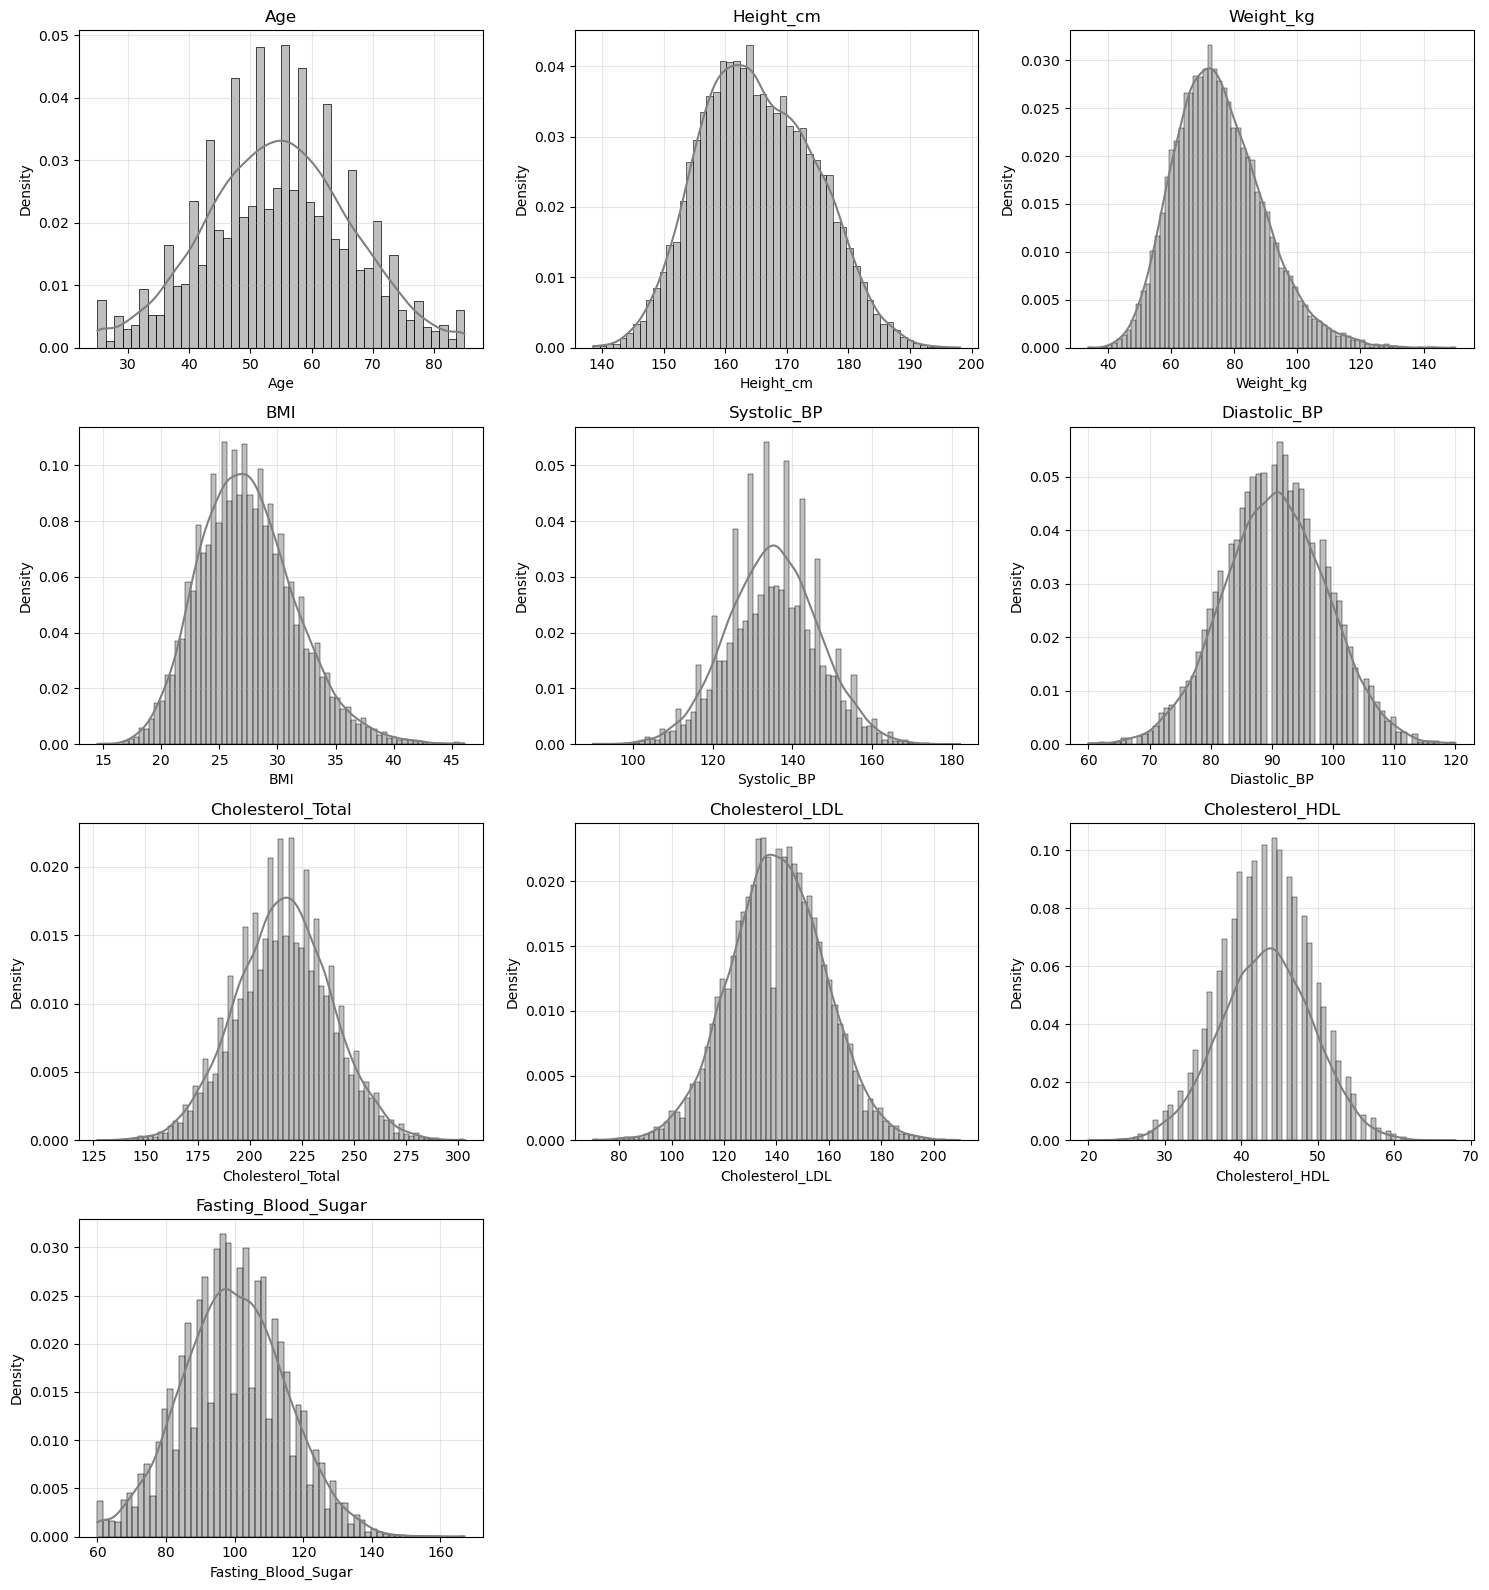

In [6]:
#on l'utilise sur notre dataset original 
plot_quantitative(health)

On transforme nos données pour avoir des distributions Gaussiennes (expliquer pourquoi). On trace les histogrammes de nos nouvelles variables

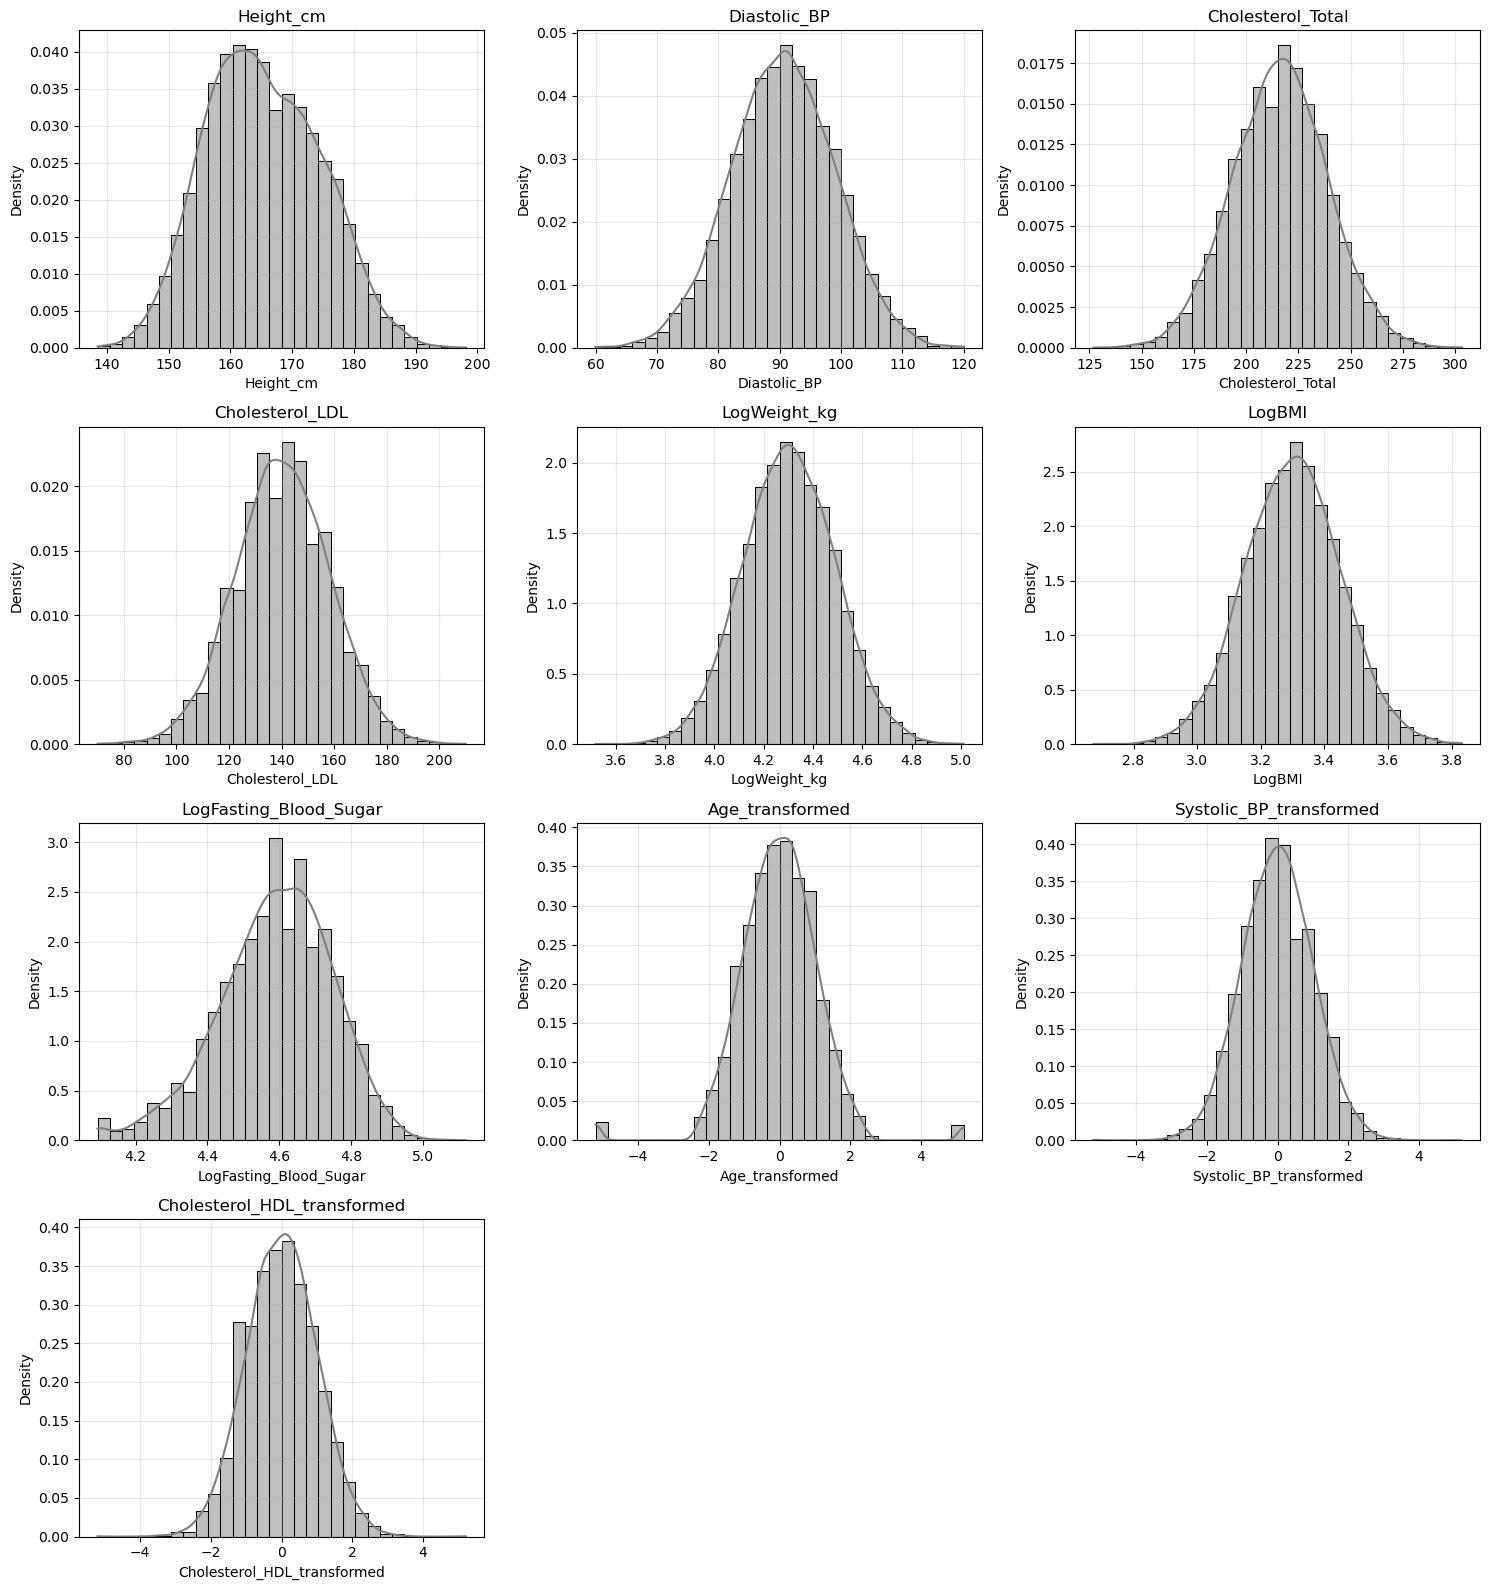

In [11]:
# on applique une transformation LOG sur les variables très asymétriques 
log_transformations = {
    "Weight_kg": "LogWeight_kg",
    "BMI": "LogBMI",
    "Fasting_Blood_Sugar": "LogFasting_Blood_Sugar"
}

#on applique une transformation QUANTILE sur les variables avec des outliers
# cette transformation tri les données et associe à chaque valeur un quantile de la distribution normale
qt_transformations = {
    "Age": "Age_transformed",
    "Systolic_BP": "Systolic_transformed",
    "Cholesterol_HDL": "Cholesterol_transformed"
}

# cette boucle nous permet de pouvoir relancer la cellule plusieurs fois sans erreur. Si la source n'existe plus, on ne fait rien
for old_col, new_col in log_transformations.items():
    if old_col in health.columns:
        health[new_col] = np.log(health[old_col])
        health = health.drop(columns=[old_col]) # On supprime l'originale tout de suite


from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution='normal', n_quantiles=100)
#pareil pour la transformation quantile
for old_col, new_col in qt_transformations.items():
    if old_col in health.columns:
        health[new_col] = qt.fit_transform(health[[old_col]])
        health = health.drop(columns=[old_col])

# 4. Affichage
plot_quantitative(health)

On peut voir qu'il y a encore des défauts, on observe des "pics" ou des "trous" et des valeurs aberrantes. Cependant, ceci est lié à l'arrondi des données de santé, l'affichage... Les données sont assez gaussiennes pour notre utilisation. (je crois, à vérifier)

### transformation des données pour l'apprentissage 

In [18]:
#on définit la cible : le Heart_Disease_Risk, celle ci est binaire et indique si le patient est à risque de maladie cardiaque ou non
health_target = health['Heart_Disease_Risk']

health_features = health.drop(['Heart_Disease_Risk', 'Patient_ID'], axis=1)# Patient_ID est une variable catégorielle qui n'apporte pas d'information pour la prédiction

health_features = pd.get_dummies(health_features, columns=['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption'], drop_first=True)


note : on a mit en "dummies" uniquement les variables binaires, les variables telles que Stress_level par exemple ne sont pas mises en dummies, car elles sont "ordonnées" 

(est ce que c'est bien?)

On split le data set. En effet, nous souhaitons mettre en place une procédure permettant de séléctionner le meilleur modèle. On dooit donc pouvoir tester chqaue modèle sur un dataset de test, afin de detecter par exemple l'over fitting

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(health_features, health_target, test_size=0.2, train_size=0.8) # on renomme en X/y pour la lisibilité
print("la dimension de X_train est : ", np.shape(X_train))
print("la dimension de X_test est : ", np.shape(X_test))
print("la dimension de Y_train est : ", np.shape(Y_train))
print("la dimension de Y_test est : ", np.shape(Y_test))


la dimension de X_train est :  (12000, 18)
la dimension de X_test est :  (3000, 18)
la dimension de Y_train est :  (12000,)
la dimension de Y_test est :  (3000,)


On normalise les variables. (dire pourquoi)

In [21]:
from sklearn.preprocessing import StandardScaler  

scaler = StandardScaler()  
scaler.fit(X_train)  
Xs_train= scaler.transform(X_train)  
# Meme transformation sur le test -> on part du principe que les données de test suivent la même distribution que les données d'entraînement, on applique donc la même transformation
Xs_test= scaler.transform(X_test)

## Modèles linéaires 

### Modèle linéaire sans pénalisation, sans séléction de variable 

La variable qu'on cherche à prédire, "Heart_Disease_Risk" est binaire, on utilise donc une régréssion logistique 

Question= à quoi correspondent les itérations ?

In [ ]:
from sklearn.linear_model import LogisticRegression

logReg_none = LogisticRegression(penalty=None, max_iter=10000) # on initialise le modèle, le max_iter est mis à 10000 pour être sûr que le modèle converge, on veut faire sans pénalité pour commencer.  
logReg_none.fit(Xs_train, Y_train)

LogisticRegression(max_iter=10000, penalty=None)

On observe les résultats, on regarde les performances sur le dataset de test

In [27]:
from sklearn.metrics import accuracy_score, classification_report

# Prédiction
Y_pred_lrn = logReg_none.predict(Xs_test)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_lrn):.2%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_lrn))

Précision du modèle : 72.20%
              precision    recall  f1-score   support

           0       0.73      0.80      0.77      1699
           1       0.70      0.62      0.66      1301

    accuracy                           0.72      3000
   macro avg       0.72      0.71      0.71      3000
weighted avg       0.72      0.72      0.72      3000



On fait la matrice de confusions (c ça le nom ?)

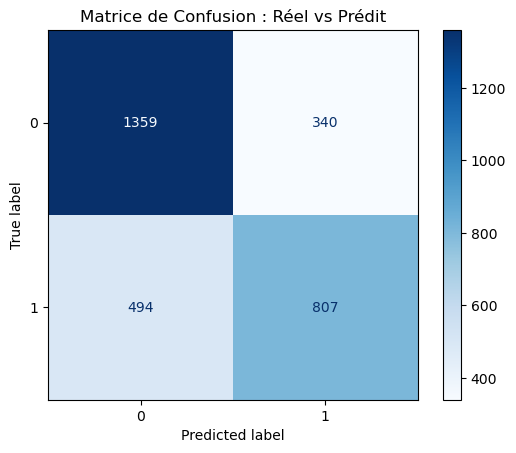

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Générer la matrice
cm = confusion_matrix(Y_test, Y_pred_lrn)

# L'afficher de manière élégante
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logReg_none.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion : Réel vs Prédit")
plt.show()

### Modèle linéaire avec pénalisation LASSO 

$$\widehat{\beta}_{\text{Lasso}} = \text{argmin}_{\beta \in \mathbb{R}^{p+1}} \left( \sum_{i=1}^{n} (Y_i - \sum_{j=0}^{p} X_i^{(j)}\beta_j)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right)$$

Cette pénalité ajoute une pénalité au modèle s'il utilise trop de variables ou des coefficients trop grand. Il élimine les variables inutiles, et évite l'overfitting

note : vérifier que L1 c lasso

In [31]:
logReg_lasso = LogisticRegression(penalty='l1',solver='saga', max_iter=10000) #L1= lasso. Saga doit être utilisé pour la pénalité L1 car le solveur par défaut (liblinear) ne supporte pas la pénalité L1 
logReg_lasso.fit(Xs_train, Y_train)

LogisticRegression(max_iter=10000, penalty='l1', solver='saga')

In [32]:
# Prédiction
Y_pred_lrl = logReg_lasso.predict(Xs_test)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_lrl):.2%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_lrl))

Précision du modèle : 72.27%
              precision    recall  f1-score   support

           0       0.73      0.80      0.77      1699
           1       0.70      0.62      0.66      1301

    accuracy                           0.72      3000
   macro avg       0.72      0.71      0.71      3000
weighted avg       0.72      0.72      0.72      3000



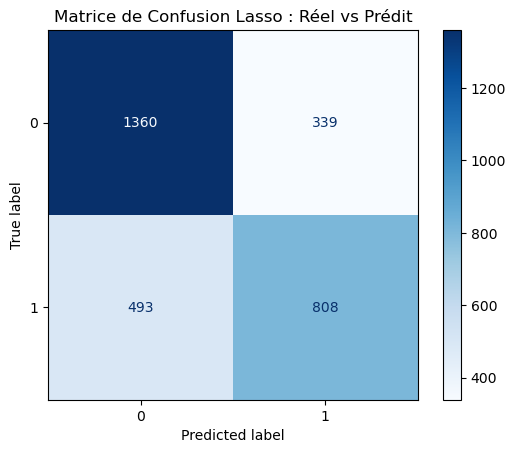

In [33]:
# Générer la matrice
cm = confusion_matrix(Y_test, Y_pred_lrl)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logReg_lasso.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Lasso : Réel vs Prédit")
plt.show()